In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
conn=sqlite3.connect('customer_churn.db')

sql_query="""
      SELECT name
      FROM sqlite_master
      Where type='table'
"""
tables=pd.read_sql(sql_query,conn)

for table_name in tables['name']:
 df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
 globals()[f"df_{table_name}"]=df
 print(f"Created dataframe :df_{table_name}")

conn.close()



Created dataframe :df_db_customer
Created dataframe :df_db_subscription
Created dataframe :df_db_support


In [ ]:
conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
  print(f"\nTable Name:{table_name}")

columns_query=f"PRAGMA table_info({table_name})"
columns=pd.read_sql(columns_query,conn)
print(columns)

conn.close()


Table Name:db_customer

Table Name:db_subscription

Table Name:db_support
   cid            name       type  notnull dflt_value  pk
0    0      customerid       TEXT        0       None   0
1    1  complaint_date  TIMESTAMP        0       None   0
2    2     escalations       TEXT        0       None   0
3    3      csat_score    INTEGER        0       None   0
4    4           col_1       REAL        0       None   0
5    5         comment       TEXT        0       None   0


**DATA CLEANING**

In [ ]:
df=df_db_customer.head()

In [ ]:
df.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  5 non-null      object
 1   name        5 non-null      object
 2   country     5 non-null      object
 3   state       5 non-null      object
 4   gender      5 non-null      object
 5   dob         5 non-null      object
 6   interests   3 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 452.0+ bytes


In [ ]:
# rename name

df.rename(columns={'name':'customer_name'},inplace=True)

/tmp/ipykernel_1044/1689270522.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'name':'customer_name'},inplace=True)


In [ ]:
# drop columns-interests and pincode

df.drop(columns={'interests','pincode'})

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [ ]:
# dob Data types Change

df['dob']=pd.to_datetime(df['dob'])

/tmp/ipykernel_1044/614011690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dob']=pd.to_datetime(df['dob'])


In [ ]:
df['dob']

,dob
0,1982-04-12
1,1995-11-23
2,1978-02-15
3,2001-08-30
4,1990-05-05


In [ ]:
# dat standardization-gender

df['gender'].replace({'Men':'Male','Women':'Female'})

,gender
0,Male
1,Male
2,Female
3,Male
4,Female


In [ ]:
# Contry and State

df_db_customer['country'].isna()

,country
0,False
1,False
2,False
3,False
4,False
5,True
6,False
7,False
8,True
9,False


In [ ]:
Mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(Mapping))

#**SUBSCRIPTION**

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [ ]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [ ]:
date_columns=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_columns].apply(pd.to_datetime)

,subscription_start_date,renewal_date,cancellation_date
0,2021-03-15,2025-03-15,NaT
1,2020-08-01,2024-08-01,2024-09-10
2,2022-11-20,2025-11-20,NaT
3,2019-05-10,2025-05-10,NaT
4,2023-01-05,2024-01-05,2024-02-28
5,2022-06-18,2025-06-18,NaT
6,2021-09-30,2024-09-30,2024-11-15
7,2020-02-14,2025-02-14,NaT
8,2023-07-22,2024-07-22,NaT
9,2022-04-03,2025-04-03,NaT


#**SUPPORT**

In [ ]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [ ]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [ ]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [ ]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [ ]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [ ]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [ ]:
df_db_customer.nunique()

,0
customerid,21
name,21
country,2
state,9
gender,4
dob,21
interests,4
pincode,0


In [ ]:
df_db_subscription.nunique()

,0
customerid,21
subscription_start_date,21
subscription_type,3
renewal_date,21
plan_type,3
contract_type,2
cancellation_date,6
cancellation_reason,5
monthly_charges,10
cltv,21


In [ ]:
df_db_support.nunique()

,0
customerid,7
complaint_date,8
escalations,2
csat_score,6


In [ ]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [ ]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates(subset='customerid',keep='last')

In [ ]:
df1=(df_db_subscription
.merge(df_db_customer,on='customerid',how='left')
.merge(df_db_support,on='customerid',how='left'))

In [ ]:
df1.shape

(21, 23)

#**DATA ANALYSIS**

In [ ]:
df1.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='object')

In [ ]:
churn_rate=df1['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [ ]:
# Churn by Plan Type

churn_by_plan=df1.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate')

print(churn_by_plan)

  plan_type  churn_rate
0     Basic       60.00
1   Premium       14.29
2  Standard       22.22


In [ ]:
# Avg Revenue per user

ARPU=df1['monthly_charges'].mean()
print('ARPU=',round(ARPU,2))

ARPU= 18.85


In [ ]:
# Avg Customer Tenure

df1['subscription_start_date'] = pd.to_datetime(
    df1['subscription_start_date'],
    errors='coerce'
)

df1['cancellation_date'] = pd.to_datetime(
    df1['cancellation_date'],
    errors='coerce'
)

# Today's date
today = pd.Timestamp.today().normalize()

# Calculate tenure in days

df1['tenure_days'] = np.where(
    df1['cancellation_date'].notna(),
    (df1['cancellation_date'] - df1['subscription_start_date']).dt.days,
    (today - df1['subscription_start_date']).dt.days
)

In [ ]:
avg_tenure=df1['tenure_days'].mean()
print("Avg Tenure (days)=",avg_tenure)

Avg Tenure (days)= 1539.4285714285713


In [ ]:
revenue_at_risk = df1.loc[df1['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk=", revenue_at_risk)

Revenue at Risk= 73.94


In [ ]:
# Average complaints per user

Avg_complaints = (
    df1['complaint_count'].sum()
    / df1['customerid'].nunique()
)

print("Avg Complaints per User =", round(Avg_complaints, 2))

Avg Complaints per User = 0.43


In [ ]:
# Correlation

df1[['escalations','churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [ ]:
# Churn risk

conditions = [
    df1['churn_score'] < 50,
    (df1['churn_score'] >= 50) & (df1['churn_score'] < 70),
    df1['churn_score'] >= 70
]

choices = ['low', 'med', 'high']

df1['churn_risk'] = np.select(
    conditions,
    choices,
    default='unknown'
)

#**VISUALIZATION**

In [ ]:
df_visual=df1.copy()

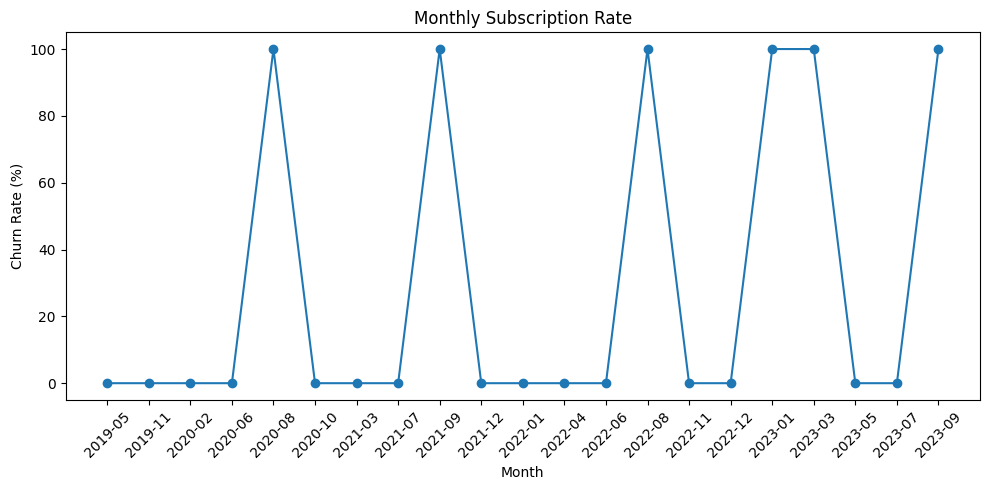

In [ ]:
# Monthly Subsciption Trend

monthly_churn = (
    df_visual.groupby(df_visual['subscription_start_date'].dt.to_period('M'))
    ['churn_flag']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate')
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_churn['subscription_start_date'].astype(str),
    monthly_churn['churn_rate'],
    marker='o'
)

plt.title('Monthly Subscription Rate')
plt.xlabel('Month')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


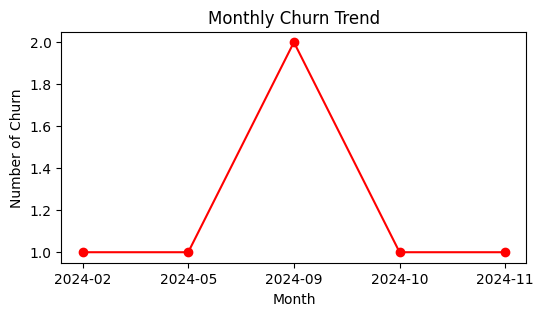

In [ ]:
# Monthly Churn Trend

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(6,3))

plt.plot(churn_trend.index.astype('str'),churn_trend.values,marker='o',color='red')
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Number of Churn')
plt.show()



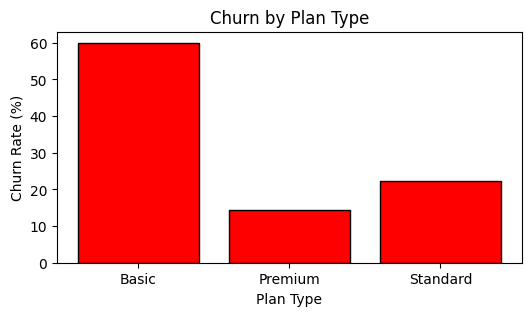

In [ ]:
# Churn by Plan Type

df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(6,3))

plt.bar(churn_by_plan['plan_type'],churn_by_plan['churn_rate'],color='r',edgecolor='Black'
)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Text(0, 0.5, 'Churn Rate (%)')

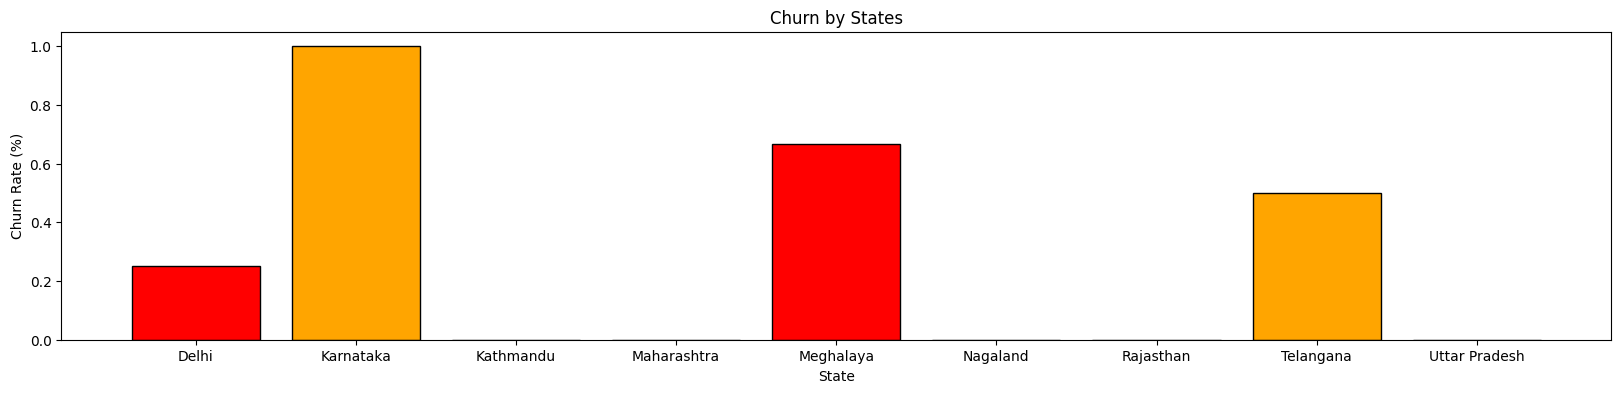

In [ ]:
# Churn by States

churn_plan =df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize=(20,4))

colors= ['red','orange']
plt.bar(churn_plan.index,churn_plan.values,edgecolor='black',color=colors)
plt.title('Churn by States')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
